In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import EfficientFrontier, risk_models, expected_returns
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go
from datetime import date
from dateutil.relativedelta import relativedelta
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')
import matplotlib.cm as cm

In [3]:
risco = ["^IRX"]
eend_date = date(2025, 6, 24)  #end_date or date(2025, 5, 1)
sstart_date = date(2025, 6, 23) #start_date or (self.end_date + relativedelta(months=-12))  # Aumentado para 6 meses
pprices = None
rreturns = None
#benchmark_ticker = "BTC-USD"
#
#"""Download e preparação dos dados"""
print(f"Baixando dados de {sstart_date} até {eend_date}...")
pprices_raw = yf.download(risco, start=sstart_date, end=eend_date)
pprices = pprices_raw['Close']# if len(tickers) > 1 else pd.DataFrame({tickers[0]: prices_raw['Close']})
#    
#    # Calcula retornos logarítmicos diários
#returns = np.log(prices / prices.shift(1)).dropna()
#    
#print(f"Dados baixados com sucesso. Período: {len(returns)} dias úteis")


prices

[*********************100%***********************]  1 of 1 completed

Baixando dados de 2025-06-23 até 2025-06-24...


Ticker,^IRX
Date,
2025-06-23,4.158


In [4]:
# =============================================================================
# CONFIGURAÇÕES E DADOS
# =============================================================================

class CryptoPortfolioAnalyzer:
    def __init__(self, tickers, start_date=None, end_date=None):
        self.tickers = tickers
        self.end_date = date(2025, 1, 1)  #end_date or date(2025, 5, 1)
        self.start_date = date(2024, 1, 1) #start_date or (self.end_date + relativedelta(months=-12))  # Aumentado para 6 meses
        self.prices = None
        self.returns = None
        self.benchmark_ticker = "BTC-USD"
        
    def download_data(self):
        """Download e preparação dos dados"""
        print(f"Baixando dados de {self.start_date} até {self.end_date}...")
        try:
            prices_raw = yf.download(self.tickers, start=self.start_date, end=self.end_date)
            self.prices = prices_raw['Close'] if len(self.tickers) > 1 else pd.DataFrame({self.tickers[0]: prices_raw['Close']})
            
            # Calcula retornos logarítmicos diários
            self.returns = np.log(self.prices / self.prices.shift(1)).dropna()
            
            print(f"Dados baixados com sucesso. Período: {len(self.returns)} dias úteis")
            return True
        except Exception as e:
            print(f"Erro ao baixar dados: {e}")
            return False
            
    
    def plot_price_evolution(self):
        """Gráfico da evolução normalizada dos preços"""
        normalized_prices = self.prices / self.prices.iloc[0]
        
        plt.figure(figsize=(14, 8))
        for ticker in self.tickers:
            plt.plot(normalized_prices.index, normalized_prices[ticker], 
                    label=ticker, linewidth=2)
        
        plt.title('Evolução Normalizada dos Preços das Criptomoedas', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Data', fontweight='bold')
        plt.ylabel('Preço Normalizado (Base = 1)', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def plot_returns_distribution(self):
        """Análise da distribuição dos retornos"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Densidade dos retornos
        for ticker in self.returns.columns:
            sns.kdeplot(data=self.returns[ticker], label=ticker, 
                       fill=True, alpha=0.3, ax=ax1)
        
        ax1.set_title('Distribuição dos Retornos Diários', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Retorno', fontweight='bold')
        ax1.set_ylabel('Densidade', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Box plot dos retornos
        returns_melted = self.returns.reset_index().melt(
            id_vars='Date', var_name='Ticker', value_name='Return')
        sns.boxplot(data=returns_melted, x='Ticker', y='Return', ax=ax2)
        ax2.set_title('Box Plot dos Retornos', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Ativo', fontweight='bold')
        ax2.set_ylabel('Retorno', fontweight='bold')
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def optimize_portfolio(self, objective='sharpe', risk_free_rate=pprices):
        """Otimização robusta do portfolio com múltiplas estratégias"""
        # Remove benchmark dos ativos para otimização
        assets_returns = self.returns.drop(columns=[self.benchmark_ticker], errors='ignore')
        
        if len(assets_returns.columns) == 0:
            print("Erro: Nenhum ativo disponível para otimização")
            return None, None, None
        
        print(f"Otimizando portfolio com {len(assets_returns.columns)} ativos...")
        print(f"Período de dados: {len(assets_returns)} dias")
        
        # Estratégia 1: Usar Ledoit-Wolf Shrinkage (mais robusto)
        try:
            print("Tentativa 1: Usando Ledoit-Wolf shrinkage...")
            mu = expected_returns.mean_historical_return(assets_returns, frequency=252)
            S = risk_models.CovarianceShrinkage(assets_returns).ledoit_wolf()
            
            # Adiciona regularização manual se necessário
            if np.linalg.cond(S) > 1e12:  # Matriz mal condicionada
                print("Matriz mal condicionada, aplicando regularização...")
                regularization = 1e-5 * np.trace(S) / len(S)
                S += regularization * np.eye(len(S))
            
            ef = EfficientFrontier(mu, S, weight_bounds=(0.01, 0.5))
            
            if objective == 'sharpe':
                weights = ef.max_sharpe(risk_free_rate=risk_free_rate)
            else:
                weights = ef.min_volatility()
            
            cleaned_weights = ef.clean_weights(cutoff=0.005)
            performance = ef.portfolio_performance(risk_free_rate=risk_free_rate, verbose=False)
            
            print("✅ Otimização bem-sucedida com Ledoit-Wolf")
            return cleaned_weights, performance, assets_returns
            
        except Exception as e:
            print(f"❌ Falha na tentativa 1: {e}")
        
        # Estratégia 2: Covariância exponencial
        try:
            print("Tentativa 2: Usando covariância exponencial...")
            mu = expected_returns.ema_historical_return(assets_returns, frequency=252)
            S = risk_models.exp_cov(assets_returns, frequency=252)
            
            # Regularização
            regularization = 1e-4 * np.trace(S) / len(S)
            S += regularization * np.eye(len(S))
            
            ef = EfficientFrontier(mu, S, weight_bounds=(0.02, 0.6))
            weights = ef.min_volatility()  # Mais conservador
            
            cleaned_weights = ef.clean_weights(cutoff=0.01)
            performance = ef.portfolio_performance(risk_free_rate=risk_free_rate, verbose=False)
            
            print("✅ Otimização bem-sucedida com covariância exponencial")
            return cleaned_weights, performance, assets_returns
            
        except Exception as e:
            print(f"❌ Falha na tentativa 2: {e}")
        
        # Estratégia 3: Método simples baseado em correlação
        try:
            print("Tentativa 3: Usando método baseado em Sharpe simples...")
            
            # Calcula Sharpe ratio individual
            daily_returns = assets_returns.mean()
            daily_vol = assets_returns.std()
            sharpe_ratios = daily_returns / daily_vol
            
            # Normaliza para criar pesos
            sharpe_ratios = sharpe_ratios.fillna(0)
            sharpe_ratios = np.maximum(sharpe_ratios, 0)  # Remove valores negativos
            
            if sharpe_ratios.sum() > 0:
                weights_array = sharpe_ratios / sharpe_ratios.sum()
            else:
                weights_array = np.ones(len(assets_returns.columns)) / len(assets_returns.columns)
            
            # Converte para dicionário
            cleaned_weights = {asset: float(weight) for asset, weight in 
                             zip(assets_returns.columns, weights_array)}
            
            # Calcula performance aproximada
            port_return = np.sum(weights_array * daily_returns) * 252
            port_vol = np.sqrt(np.dot(weights_array, np.dot(assets_returns.cov() * 252, weights_array)))
            port_sharpe = port_return / port_vol if port_vol > 0 else 0
            
            performance = (port_return, port_vol, port_sharpe)
            
            print("✅ Otimização bem-sucedida com método Sharpe simples")
            return cleaned_weights, performance, assets_returns
            
        except Exception as e:
            print(f"❌ Falha na tentativa 3: {e}")
        
        # Estratégia 4: Pesos iguais (fallback final)
        print("Usando pesos iguais como fallback...")
        equal_weights = {asset: 1.0/len(assets_returns.columns) 
                        for asset in assets_returns.columns}
        
        # Calcula performance dos pesos iguais
        weights_array = np.ones(len(assets_returns.columns)) / len(assets_returns.columns)
        daily_returns = assets_returns.mean()
        port_return = np.sum(weights_array * daily_returns) * 252
        port_vol = np.sqrt(np.dot(weights_array, np.dot(assets_returns.cov() * 252, weights_array)))
        port_sharpe = port_return / port_vol if port_vol > 0 else 0
        
        performance = (port_return, port_vol, port_sharpe)
        
        print("✅ Usando portfolio com pesos iguais")
        return equal_weights, performance, assets_returns
    
    def plot_portfolio_allocation(self, weights):
        """Gráfico da alocação do portfolio"""
        weights_df = pd.DataFrame({
            'Asset': list(weights.keys()),
            'Weight': list(weights.values())
        }).sort_values('Weight', ascending=True)
        
        plt.figure(figsize=(10, 6))
        colors = cm.viridis(np.linspace(0, 1, len(weights_df)))
        plt.barh(weights_df['Asset'], weights_df['Weight'], color=colors)
        plt.title('Alocação Otimizada do Portfolio', fontsize=16, fontweight='bold')
        plt.xlabel('Peso (%)', fontweight='bold')
        plt.ylabel('Ativos', fontweight='bold')
        
        # Adiciona valores nas barras
        for i, v in enumerate(weights_df['Weight']):
            plt.text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')
        
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def calculate_portfolio_performance(self, weights, assets_returns):
        """Calcula performance do portfolio ao longo do tempo"""
        # Calcula retornos do portfolio
        portfolio_returns = pd.Series(0, index=assets_returns.index)
        
        for asset, weight in weights.items():
            if asset in assets_returns.columns:
                portfolio_returns += assets_returns[asset] * weight
        
        # Calcula retornos cumulativos
        portfolio_cumulative = (1 + portfolio_returns).cumprod()
        
        # Benchmark (se disponível)
        benchmark_cumulative = None
        if self.benchmark_ticker in self.returns.columns:
            benchmark_returns = self.returns[self.benchmark_ticker]
            benchmark_cumulative = (1 + benchmark_returns).cumprod()
        
        return portfolio_returns, portfolio_cumulative, benchmark_cumulative
    
    def plot_performance_comparison(self, portfolio_cumulative, benchmark_cumulative=None):
        """Gráfico de comparação de performance"""
        plt.figure(figsize=(14, 8))
        
        plt.plot(portfolio_cumulative.index, portfolio_cumulative, 
                label='Portfolio Otimizado', linewidth=2, color='darkblue')
        
        if benchmark_cumulative is not None:
            plt.plot(benchmark_cumulative.index, benchmark_cumulative, 
                    label=f'Benchmark ({self.benchmark_ticker})', 
                    linewidth=2, color='red', alpha=0.7)
        
        plt.title('Performance: Portfolio vs Benchmark', fontsize=16, fontweight='bold')
        plt.xlabel('Data', fontweight='bold')
        plt.ylabel('Retorno Cumulativo', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def generate_efficient_frontier(self, assets_returns, num_points=30):
        """Gera a fronteira eficiente com método robusto"""
        try:
            # Usa método mais robusto
            mu = expected_returns.ema_historical_return(assets_returns, frequency=252)
            S = risk_models.CovarianceShrinkage(assets_returns).ledoit_wolf()
            
            # Regularização
            regularization = 1e-4 * np.trace(S) / len(S)
            S += regularization * np.eye(len(S))
            
            # Range de retornos mais conservador
            min_ret = mu.min() * 0.5
            max_ret = mu.max() * 0.8
            target_returns = np.linspace(min_ret, max_ret, num_points)
            
            efficient_portfolios = []
            
            for target in target_returns:
                try:
                    ef = EfficientFrontier(mu, S, weight_bounds=(0.01, 0.8))
                    ef.efficient_return(target)
                    ret, vol, _ = ef.portfolio_performance(verbose=False)
                    if vol > 0 and ret > 0:  # Apenas pontos válidos
                        efficient_portfolios.append((ret, vol))
                except:
                    continue
            
            if efficient_portfolios:
                returns_ef, volatility_ef = zip(*efficient_portfolios)
                return np.array(returns_ef), np.array(volatility_ef)
            else:
                print("⚠️ Não foi possível gerar fronteira eficiente")
                return np.array([]), np.array([])
                
        except Exception as e:
            print(f"⚠️ Erro na fronteira eficiente: {e}")
            return np.array([]), np.array([])
    
    def monte_carlo_simulation(self, assets_returns, num_simulations=5000):
        """Simulação Monte Carlo para portfolios aleatórios"""
        np.random.seed(42)
        
        num_assets = len(assets_returns.columns)
        results = np.zeros((4, num_simulations))  # [retorno, volatilidade, sharpe, pesos]
        
        mu = assets_returns.mean() * 252  # Anualizado
        cov = assets_returns.cov() * 252  # Anualizado
        
        for i in range(num_simulations):
            # Gera pesos aleatórios
            weights = np.random.random(num_assets)
            weights /= weights.sum()
            
            # Calcula métricas do portfolio
            portfolio_return = np.sum(weights * mu)
            portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
            sharpe_ratio = portfolio_return / portfolio_volatility if portfolio_volatility > 0 else 0
            
            results[0, i] = portfolio_return
            results[1, i] = portfolio_volatility
            results[2, i] = sharpe_ratio
        
        return results
    
    def plot_efficient_frontier_with_simulation(self, assets_returns, optimal_weights):
        """Plota fronteira eficiente com simulação Monte Carlo - versão robusta"""
        # Simulação Monte Carlo
        mc_results = self.monte_carlo_simulation(assets_returns)
        
        # Performance do portfolio otimizado
        try:
            mu = assets_returns.mean() * 252  # Anualizado
            cov_matrix = assets_returns.cov() * 252  # Anualizado
            
            weights_array = np.array([optimal_weights.get(asset, 0) for asset in assets_returns.columns])
            
            opt_return = np.sum(weights_array * mu)
            opt_volatility = np.sqrt(np.dot(weights_array, np.dot(cov_matrix, weights_array)))
            
        except Exception as e:
            print(f"⚠️ Erro no cálculo do portfolio otimizado: {e}")
            opt_return, opt_volatility = 0, 0
        
        plt.figure(figsize=(12, 8))
        
        # Simulação Monte Carlo
        if mc_results.size > 0:
            scatter = plt.scatter(mc_results[1], mc_results[0], 
                                c=mc_results[2], cmap='viridis', 
                                alpha=0.6, s=20)
            plt.colorbar(scatter, label='Sharpe Ratio')
            #plt.plot(fronteira['Riscos'], fronteira['Retornos'], 
            #    color='DarkGreen', linewidth=3, label='Fronteira Eficiente')
        
        # Fronteira eficiente (tentativa)
        try:
            ef_returns, ef_volatility = self.generate_efficient_frontier(assets_returns)
            if len(ef_returns) > 0:
                plt.plot(ef_volatility, ef_returns, 'r-', linewidth=3, 
                        label='Fronteira Eficiente')
        except:
            print("⚠️ Fronteira eficiente não disponível")

       
        
        # Portfolio otimizado
        if opt_volatility > 0 and opt_return > 0:
            plt.scatter(opt_volatility, opt_return, color='red', 
                       s=200, marker='*', label='Portfolio Otimizado', 
                       edgecolors='black', linewidth=2)
        
        plt.title('Análise de Portfolio: Simulação Monte Carlo', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Volatilidade (Risco)', fontweight='bold')
        plt.ylabel('Retorno Esperado', fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def print_performance_summary(self, weights, performance, portfolio_returns):
        """Imprime resumo da performance"""
        print("=" * 60)
        print("RESUMO DA ANÁLISE DO PORTFOLIO")
        print("=" * 60)
        
        # Informações do portfolio
        print(f"\n📊 COMPOSIÇÃO DO PORTFOLIO:")
        for asset, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
            if weight > 0.01:  # Apenas pesos > 1%
                print(f"   {asset}: {weight:.1%}")
        
        print(f"\n📈 PERFORMANCE ESPERADA (Anualizada):")
        print(f"   Retorno Esperado: {performance[0]:.2%}")
        print(f"   Volatilidade: {performance[1]:.2%}")
        print(f"   Sharpe Ratio: {performance[2]:.3f}")
        
        # Estatísticas dos retornos realizados
        print(f"\n📊 ESTATÍSTICAS DOS RETORNOS (Período):")
        print(f"   Retorno Médio Diário: {portfolio_returns.mean():.4%}")
        print(f"   Volatilidade Diária: {portfolio_returns.std():.4%}")
        print(f"   Melhor Dia: {portfolio_returns.max():.2%}")
        print(f"   Pior Dia: {portfolio_returns.min():.2%}")
        
        # Métricas de risco
        var_95 = np.percentile(portfolio_returns, 5)
        print(f"   VaR 95%: {var_95:.2%}")
        
        print("=" * 60)

Baixando dados de 2024-01-01 até 2025-01-01...


[*********************100%***********************]  6 of 6 completed


Dados baixados com sucesso. Período: 365 dias úteis

1. Gerando gráficos exploratórios...


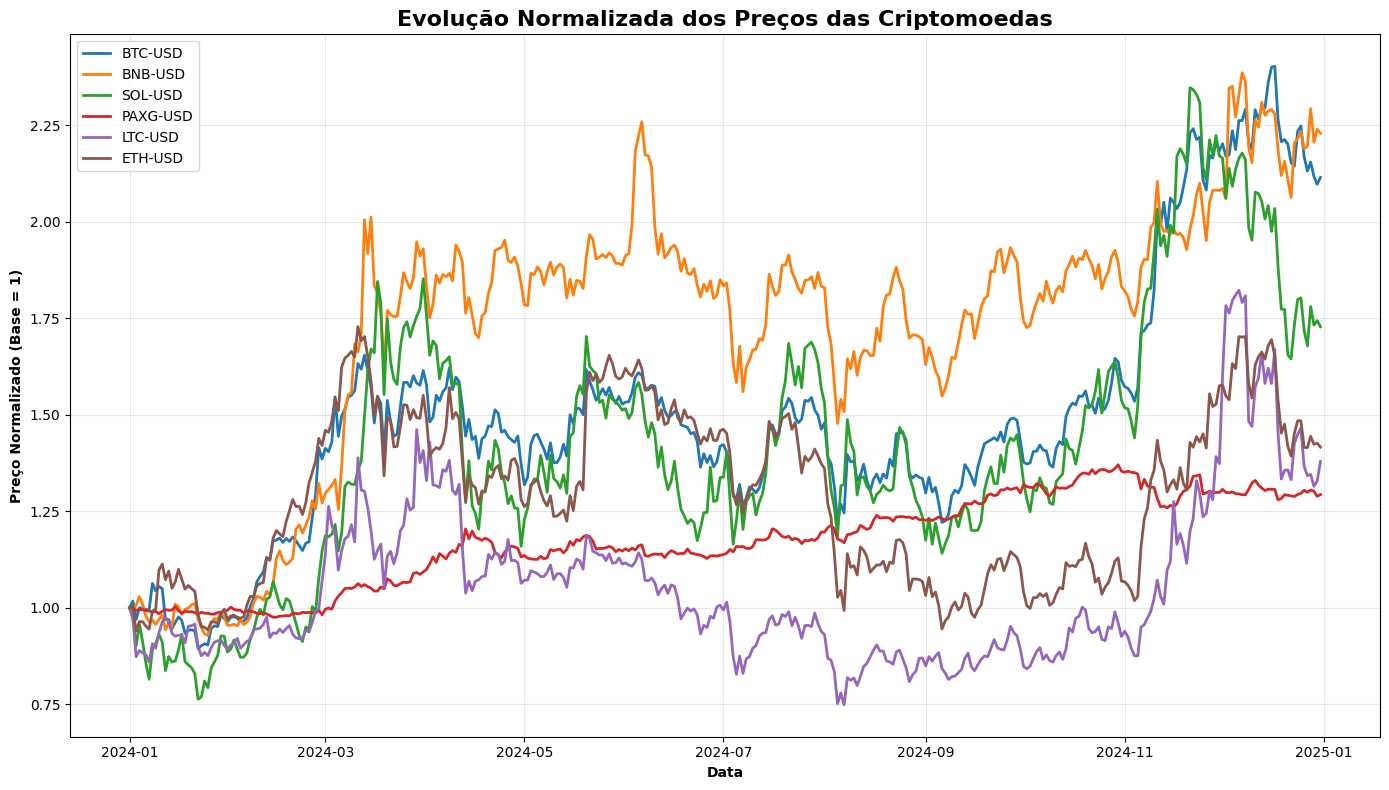

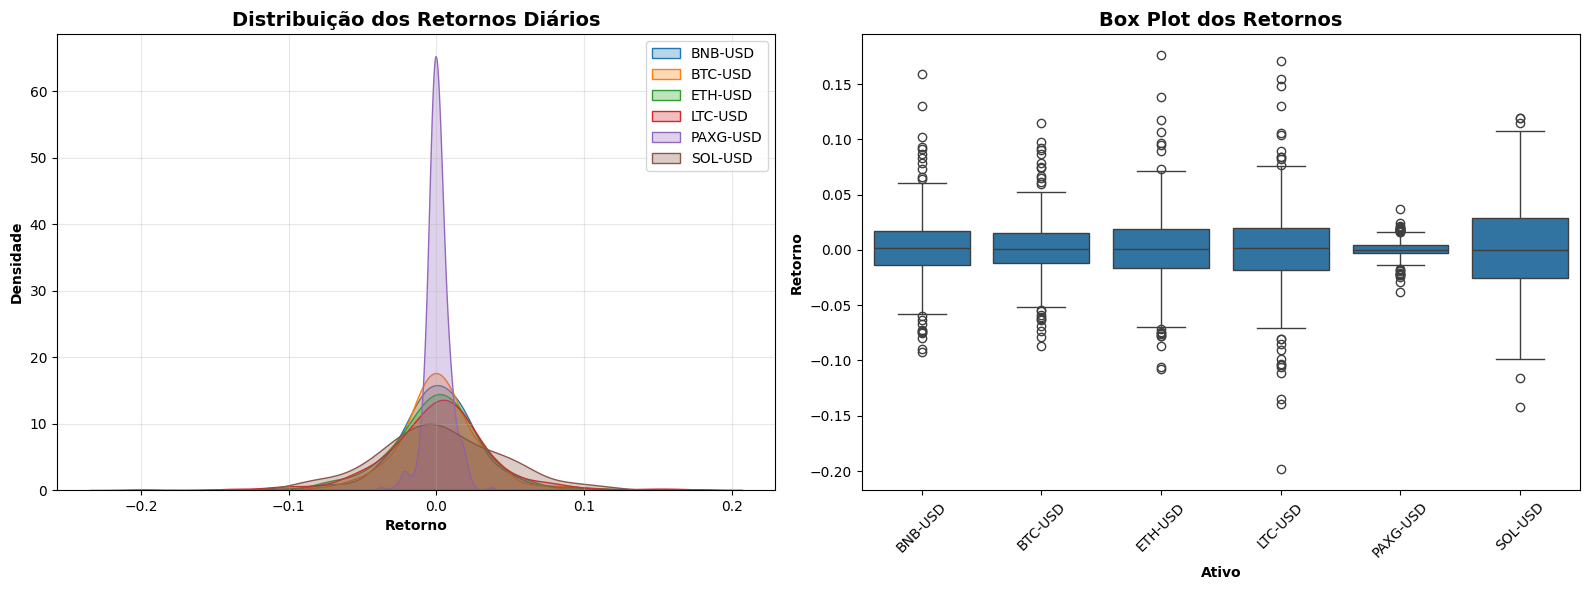


2. Otimizando portfolio...
Otimizando portfolio com 5 ativos...
Período de dados: 365 dias
Tentativa 1: Usando Ledoit-Wolf shrinkage...
❌ Falha na tentativa 1: risk_free_rate should be numeric
Tentativa 2: Usando covariância exponencial...
❌ Falha na tentativa 2: 'DivExpression' object has no attribute 'dtype'
Tentativa 3: Usando método baseado em Sharpe simples...
✅ Otimização bem-sucedida com método Sharpe simples

3. Gerando visualizações do portfolio otimizado...


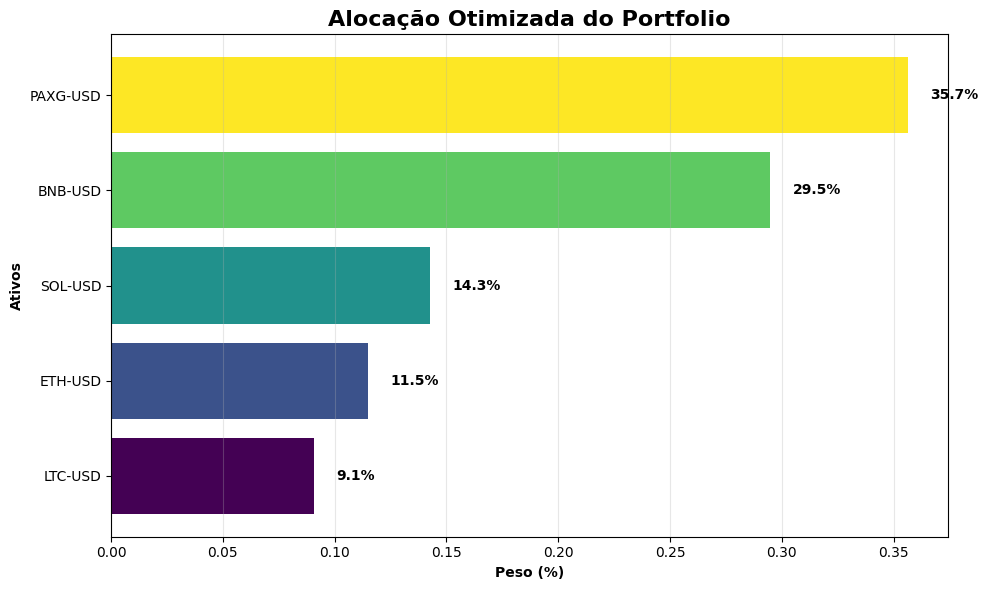


4. Calculando performance...


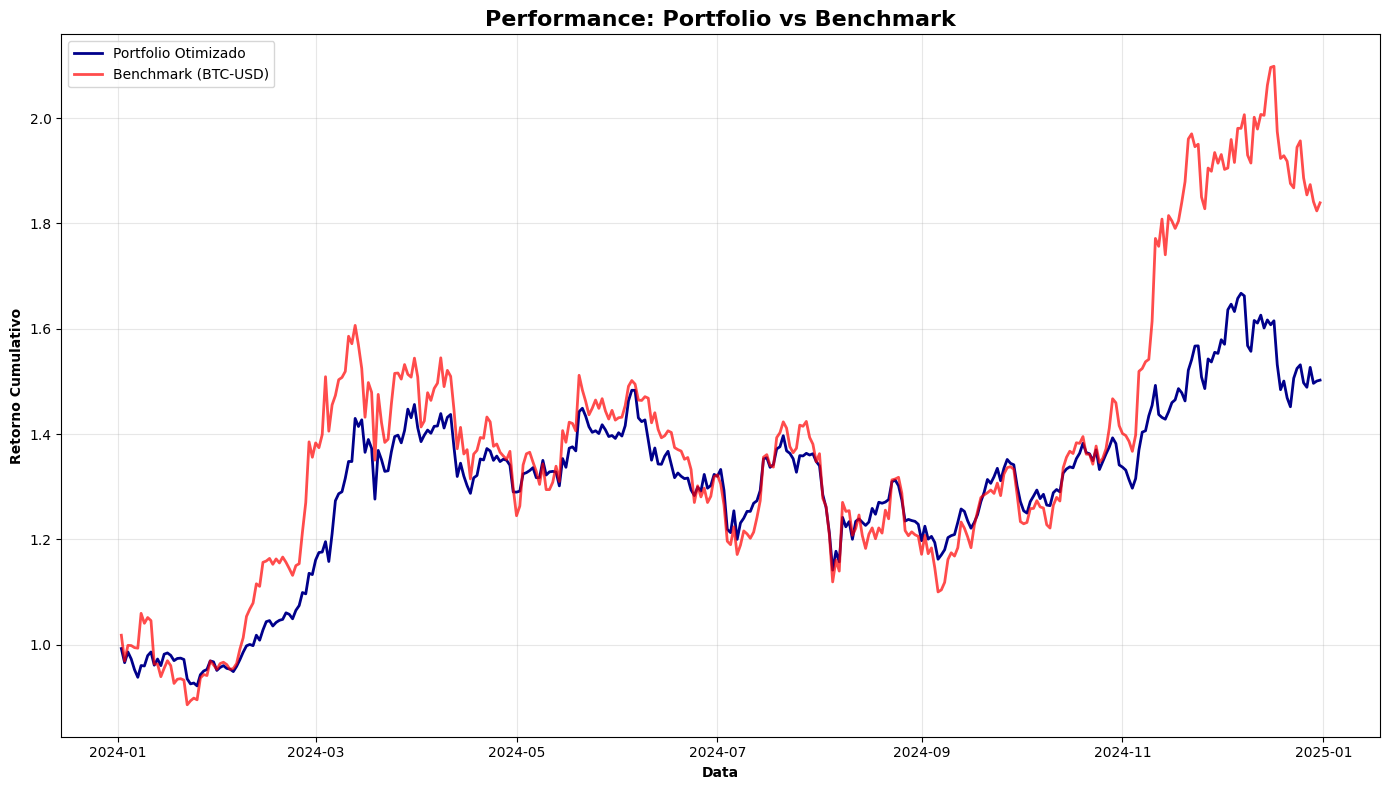


5. Gerando fronteira eficiente...
⚠️ Não foi possível gerar fronteira eficiente


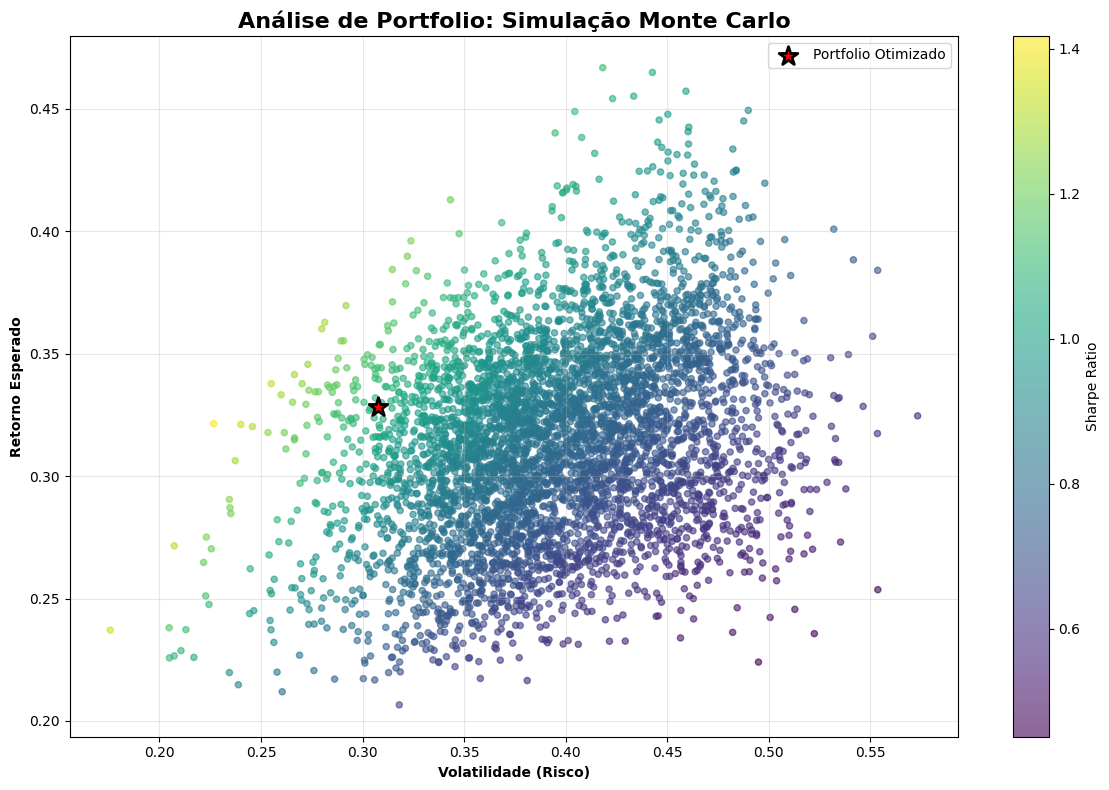

RESUMO DA ANÁLISE DO PORTFOLIO

📊 COMPOSIÇÃO DO PORTFOLIO:
   PAXG-USD: 35.7%
   BNB-USD: 29.5%
   SOL-USD: 14.3%
   ETH-USD: 11.5%
   LTC-USD: 9.1%

📈 PERFORMANCE ESPERADA (Anualizada):
   Retorno Esperado: 32.84%
   Volatilidade: 30.76%
   Sharpe Ratio: 1.067

📊 ESTATÍSTICAS DOS RETORNOS (Período):
   Retorno Médio Diário: 0.1303%
   Volatilidade Diária: 1.9379%
   Melhor Dia: 7.31%
   Pior Dia: -7.02%
   VaR 95%: -3.10%

✅ Análise concluída com sucesso!


In [5]:
# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

def main():
    # Configuração
    #tickers = ["BTC-USD", "BNB-USD", "SOL-USD", "ETH-USD", "LTC-USD"]
    tickers = ["BTC-USD", "BNB-USD", "SOL-USD", "PAXG-USD", "LTC-USD", "ETH-USD"]
    # Inicializa analisador
    analyzer = CryptoPortfolioAnalyzer(tickers)
    
    # Download dos dados
    if not analyzer.download_data():
        return
    
    # Análises exploratórias
    print("\n1. Gerando gráficos exploratórios...")
    analyzer.plot_price_evolution()
    analyzer.plot_returns_distribution()
    
    # Otimização do portfolio
    print("\n2. Otimizando portfolio...")
    weights, performance, assets_returns = analyzer.optimize_portfolio(objective='sharpe')
    
    if weights is None:
        print("Erro na otimização. Encerrando análise.")
        return
    
    # Visualizações da otimização
    print("\n3. Gerando visualizações do portfolio otimizado...")
    analyzer.plot_portfolio_allocation(weights)
    
    # Análise de performance
    print("\n4. Calculando performance...")
    portfolio_returns, portfolio_cumulative, benchmark_cumulative = analyzer.calculate_portfolio_performance(
        weights, assets_returns)
    
    analyzer.plot_performance_comparison(portfolio_cumulative, benchmark_cumulative)
    
    # Fronteira eficiente
    print("\n5. Gerando fronteira eficiente...")
    analyzer.plot_efficient_frontier_with_simulation(assets_returns, weights)
    
    # Resumo final
    analyzer.print_performance_summary(weights, performance, portfolio_returns)
    
    print("\n✅ Análise concluída com sucesso!")

if __name__ == "__main__":
    main()